# 08 -- Betting Value Finder

**What this does:**
1. You paste an event URL and American odds for each fight
2. Production models predict win probabilities
3. Converts American odds to implied probability (vig removed)
4. Calculates edge = model probability - fair implied probability
5. Filters: all 3 models unanimous **and** confidence >= 55%
6. Sizes bets with **half-Kelly criterion**
7. Outputs a bet card with stakes, edge, and risk summary

**Betting rules (hardcoded):**
- Only bet when all 3 models are **unanimous**
- Only bet when ensemble confidence **>= 55%** (MEDIUM tier+)
- Only bet when **positive edge** exists
- Stake = half Kelly = (edge / (decimal_odds - 1)) / 2

## Edit the next cell

| Field | What to enter |
|-------|---------------|
| `EVENT_URL` | UFCStats event URL, or `None` to auto-detect latest |
| `BANKROLL` | Total dollars you are willing to risk on this card |
| `ODDS` | One dict per fight: `fighter_1` (red), `fighter_2` (blue), American odds |

Fighter names must match the UFCStats card closely (fuzzy matching handles small typos).

In [27]:
# ==============================================================
# EDIT THIS CELL
# ==============================================================

EVENT_URL = "http://www.ufcstats.com/event-details/c3ac8d0da7b05772"

BANKROLL = 1000

ODDS = [
    {"fighter_1": "Jamie Siraj",            "fighter_2": "John Yannis",             "odds_1": -270, "odds_2": +220},
    {"fighter_1": "John Castaneda",         "fighter_2": "Mark Vologdin",           "odds_1": -125, "odds_2": +105},
    {"fighter_1": "Jamey-Lyn Horth",        "fighter_2": "JJ Aldrich",             "odds_1": -162, "odds_2": +136},
    {"fighter_1": "Allan Nascimento",       "fighter_2": "Mitch Raposo",           "odds_1": -192, "odds_2": +160},
    {"fighter_1": "Melissa Croden",         "fighter_2": "Daria Zhelezniakova",    "odds_1": -155, "odds_2": +130},
    {"fighter_1": "Gokhan Saricam",         "fighter_2": "Tanner Boser",           "odds_1": -155, "odds_2": +130},
    {"fighter_1": "Robert Valentin Frey",   "fighter_2": "Julien Leblanc",         "odds_1": -135, "odds_2": +114},
    {"fighter_1": "Marcio Barbosa",         "fighter_2": "Dennis Buzukja",         "odds_1": -485, "odds_2": +370},
    {"fighter_1": "Thiago Moises",          "fighter_2": "Gauge Young",            "odds_1": -130, "odds_2": +110},
    {"fighter_1": "Jasmine Jasudavicius",   "fighter_2": "Karine Silva",           "odds_1": -310, "odds_2": +250},
    {"fighter_1": "Mandel Nallo",           "fighter_2": "Jai Herbert",            "odds_1": -170, "odds_2": +142},
    {"fighter_1": "Kyler Phillips",         "fighter_2": "Charles Jourdain",       "odds_1": -155, "odds_2": +130},
    {"fighter_1": "Mike Malott",            "fighter_2": "Gilbert Burns",          "odds_1": -310, "odds_2": +250},
]

In [28]:
import pandas as pd, numpy as np, json, warnings, time, re
from pathlib import Path
from datetime import datetime
from difflib import SequenceMatcher

import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

from xgboost import XGBClassifier
import lightgbm as lgbm
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='colorblind')

# -- paths --
DATA = Path('./data') if Path('./data/model_data.csv').exists() else Path('../data')
MODEL_DIR = Path('../models') if Path('../models/xgb_prod.json').exists() else Path('./models')

# -- data --
model_data = pd.read_csv(DATA / 'model_data.csv', parse_dates=['event_date'])
model_data = model_data.sort_values('event_date').reset_index(drop=True)

fighters_clean = pd.read_csv(DATA / 'fighters_clean.csv')

with open(DATA / 'feature_list.txt') as f:
    FEATURES = [l.strip() for l in f if l.strip()]

# -- models --
xgb_mod = XGBClassifier()
xgb_mod.load_model(str(MODEL_DIR / 'xgb_prod.json'))

lgb_mod = lgbm.Booster(model_file=str(MODEL_DIR / 'lgb_prod.txt'))

cat_mod = CatBoostClassifier()
cat_mod.load_model(str(MODEL_DIR / 'cat_prod.cbm'))

# -- ensemble weights --
with open(DATA / 'best_params.json') as f:
    bp = json.load(f)
ew = bp.get('ensemble_weights', {'xgb': 1/3, 'lgb': 1/3, 'cat': 1/3})
W = {k: ew.get(k, 1/3) for k in ('xgb', 'lgb', 'cat')}

print(f'Data         : {len(model_data):,} fights')
print(f'Features     : {len(FEATURES)}')
print(f"Weights      : XGB={W['xgb']:.3f}  LGB={W['lgb']:.3f}  CAT={W['cat']:.3f}")

Data         : 5,485 fights
Features     : 310
Weights      : XGB=0.333  LGB=0.333  CAT=0.333


In [29]:
# -- odds conversion --

def american_to_decimal(am):
    # American to decimal odds
    return (1 + am / 100) if am > 0 else (1 + 100 / abs(am))

def american_to_implied(am):
    # American to raw implied prob (includes vig)
    return 100 / (am + 100) if am > 0 else abs(am) / (abs(am) + 100)

def remove_vig(imp1, imp2):
    # Strip overround to get true probabilities
    t = imp1 + imp2
    return imp1 / t, imp2 / t

def half_kelly(edge, dec_odds):
    # Half-Kelly fraction; returns 0 when no edge
    if edge <= 0 or dec_odds <= 1:
        return 0.0
    return (edge / (dec_odds - 1)) / 2

# -- process user odds --
odds_df = pd.DataFrame(ODDS)
assert len(odds_df) > 0, 'No odds entered'
for c in ('fighter_1', 'fighter_2', 'odds_1', 'odds_2'):
    assert c in odds_df.columns, f'Missing column: {c}'

odds_df['dec_1']     = odds_df['odds_1'].apply(american_to_decimal)
odds_df['dec_2']     = odds_df['odds_2'].apply(american_to_decimal)
odds_df['imp_raw_1'] = odds_df['odds_1'].apply(american_to_implied)
odds_df['imp_raw_2'] = odds_df['odds_2'].apply(american_to_implied)
odds_df['overround'] = odds_df['imp_raw_1'] + odds_df['imp_raw_2']

fair = odds_df.apply(lambda r: remove_vig(r['imp_raw_1'], r['imp_raw_2']),
                     axis=1, result_type='expand')
odds_df['fair_1'], odds_df['fair_2'] = fair[0], fair[1]

print(f"{len(odds_df)} fights with odds  |  avg vig {odds_df['overround'].mean():.1%}")
print()
print(odds_df[['fighter_1','fighter_2','odds_1','odds_2',
               'dec_1','dec_2','fair_1','fair_2','overround']]
      .to_string(index=False, float_format='%.3f'))

13 fights with odds  |  avg vig 104.2%

           fighter_1           fighter_2  odds_1  odds_2  dec_1  dec_2  fair_1  fair_2  overround
         Jamie Siraj         John Yannis    -270     220  1.370  3.200   0.700   0.300      1.042
      John Castaneda       Mark Vologdin    -125     105  1.800  2.050   0.532   0.468      1.043
     Jamey-Lyn Horth          JJ Aldrich    -162     136  1.617  2.360   0.593   0.407      1.042
    Allan Nascimento        Mitch Raposo    -192     160  1.521  2.600   0.631   0.369      1.042
      Melissa Croden Daria Zhelezniakova    -155     130  1.645  2.300   0.583   0.417      1.043
      Gokhan Saricam        Tanner Boser    -155     130  1.645  2.300   0.583   0.417      1.043
Robert Valentin Frey      Julien Leblanc    -135     114  1.741  2.140   0.551   0.449      1.042
      Marcio Barbosa      Dennis Buzukja    -485     370  1.206  4.700   0.796   0.204      1.042
       Thiago Moises         Gauge Young    -130     110  1.769  2.100   0.543

In [30]:
HEADERS = {'User-Agent': 'Mozilla/5.0'}

def get_soup(url):
    r = requests.get(url, headers=HEADERS)
    r.raise_for_status()
    return BeautifulSoup(r.text, 'lxml')

# auto-detect if needed
if EVENT_URL is None:
    soup = get_soup('http://www.ufcstats.com/statistics/events/completed')
    link = soup.select_one('table.b-statistics__table-events tbody tr td a')
    EVENT_URL = link['href']
    print(f'Auto-detected: {EVENT_URL}')

soup = get_soup(EVENT_URL)
event_name = soup.select_one('h2.b-content__title span').get_text(strip=True)
print(f'Event: {event_name}')
print()

fight_urls = []
for r in soup.select('table.b-fight-details__table tbody tr.b-fight-details__table-row'):
    link = r.get('data-link', '')
    if link:
        fight_urls.append(link)

card = []
for furl in fight_urls:
    fs = get_soup(furl)
    names = [a.get_text(strip=True) for a in
             fs.select('div.b-fight-details__person a.b-fight-details__person-link')]
    if len(names) < 2:
        continue
    statuses = fs.select('div.b-fight-details__person i.b-fight-details__person-status')
    winner = ''
    for s, n in zip(statuses, names):
        if 'W' in s.get_text(strip=True):
            winner = n
    card.append({'fighter_1': names[0], 'fighter_2': names[1],
                 'winner': winner, 'fight_url': furl})

card_df = pd.DataFrame(card)
for _, r in card_df.iterrows():
    tag = 'done' if r['winner'] else 'upcoming'
    print(f"  [{tag:8s}] {r['fighter_1']:25s} vs {r['fighter_2']}")

Event: UFC Fight Night: Burns vs. Malott



  [upcoming] Gilbert Burns             vs Mike Malott
  [upcoming] Kyler Phillips            vs Charles Jourdain
  [upcoming] Mandel Nallo              vs Jai Herbert
  [upcoming] Jasmine Jasudavicius      vs Karine Silva
  [upcoming] Thiago Moises             vs Gauge Young
  [upcoming] Dennis Buzukja            vs Marcio Barbosa
  [upcoming] Julien Leblanc            vs Robert Valentin
  [upcoming] Tanner Boser              vs Gokhan Saricam
  [upcoming] Melissa Croden            vs Daria Zhelezniakova
  [upcoming] Mitch Raposo              vs Allan Nascimento
  [upcoming] JJ Aldrich                vs Jamey-Lyn Horth
  [upcoming] John Castaneda            vs Mark Vologdin
  [upcoming] Jamie Siraj               vs John Yannis


In [31]:
def fuzzy(name, pool, thresh=0.75):
    best, sc = None, 0
    nl = name.lower().strip()
    for c in pool:
        s = SequenceMatcher(None, nl, c.lower().strip()).ratio()
        if s > sc:
            best, sc = c, s
    return best if sc >= thresh else None

def latest_snapshot(fighter, data):
    # Most recent feature row for a fighter (check f1 then f2)
    for prefix in ('fighter_1', 'fighter_2'):
        rows = data[data[prefix] == fighter].sort_values('event_date')
        if len(rows):
            tag = 'f1' if prefix == 'fighter_1' else 'f2'
            row = rows.iloc[-1]
            return {c: row[c] for c in data.columns if c.startswith(tag + '_')}, tag
    return None, None

def rename_prefix(snap, old, new):
    return {new + k[len(old):]: v for k, v in snap.items() if k.startswith(old)}

def profile_fallback(name, fdf):
    row = fdf[fdf['full_name'] == name]
    if len(row) == 0:
        m = fuzzy(name, fdf['full_name'].tolist())
        if m:
            row = fdf[fdf['full_name'] == m]
            print(f"    fuzzy: '{name}' -> '{m}'")
    if len(row) == 0:
        return None
    r = row.iloc[0]
    return {
        'profile_win_pct':        r.get('win_pct',        np.nan),
        'profile_slpm':           r.get('slpm',           np.nan),
        'profile_sapm':           r.get('sapm',           np.nan),
        'profile_str_acc_career': r.get('str_acc_career', np.nan),
        'profile_str_def_career': r.get('str_def_career', np.nan),
        'profile_td_avg':         r.get('td_avg',         np.nan),
        'profile_td_acc_career':  r.get('td_acc_career',  np.nan),
        'profile_td_def_career':  r.get('td_def_career',  np.nan),
        'profile_sub_avg':        r.get('sub_avg',        np.nan),
        'profile_total_fights':   r.get('total_fights',   np.nan),
        'height_inches':          r.get('height_inches',  np.nan),
        'reach_inches':           r.get('reach_inches',   np.nan),
        'weight_lbs':             r.get('weight_lbs',     np.nan),
        'age':                    np.nan,
    }

# -- map odds names to card names --
card_names = set(card_df['fighter_1'].tolist() + card_df['fighter_2'].tolist())
nmap = {}
for on in set(odds_df['fighter_1'].tolist() + odds_df['fighter_2'].tolist()):
    if on in card_names:
        nmap[on] = on
    else:
        m = fuzzy(on, list(card_names))
        if m:
            nmap[on] = m
            print(f"  odds->card: '{on}' -> '{m}'")
        else:
            print(f"  WARNING: no card match for '{on}'")

# -- assemble feature rows --
pred_rows = []
for _, o in odds_df.iterrows():
    f1c = nmap.get(o['fighter_1'], o['fighter_1'])
    f2c = nmap.get(o['fighter_2'], o['fighter_2'])

    row, cov = {}, 'full'

    for side, cname, prefix in [('f1', f1c, 'f1'), ('f2', f2c, 'f2')]:
        snap, src = latest_snapshot(cname, model_data)
        if snap:
            row.update(rename_prefix(snap, src + '_', prefix + '_'))
        else:
            fb = profile_fallback(cname, fighters_clean)
            if fb:
                for k, v in fb.items():
                    row[f'{prefix}_{k}'] = v
                cov = 'profile_only'
                print(f'  WARNING: {cname}: profile-only')
            else:
                cov = 'missing'
                print(f'  ERROR: {cname}: not found')

    # differentials
    for feat in FEATURES:
        if feat.startswith('diff_'):
            base = feat[5:]
            v1 = row.get(f'f1_{base}', np.nan)
            v2 = row.get(f'f2_{base}', np.nan)
            try:
                row[feat] = float(v1) - float(v2)
            except (TypeError, ValueError):
                row[feat] = np.nan

    row.update({'fighter_1': o['fighter_1'], 'fighter_2': o['fighter_2'],
                'coverage': cov, 'odds_1': o['odds_1'], 'odds_2': o['odds_2'],
                'dec_1': o['dec_1'], 'dec_2': o['dec_2'],
                'fair_1': o['fair_1'], 'fair_2': o['fair_2']})
    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)
n_full = (pred_df['coverage']=='full').sum()
n_prof = (pred_df['coverage']=='profile_only').sum()
n_miss = (pred_df['coverage']=='missing').sum()
print(f'\nBuilt {len(pred_df)} fights  |  full={n_full}  profile_only={n_prof}  missing={n_miss}')

  odds->card: 'Robert Valentin Frey' -> 'Robert Valentin'

Built 13 fights  |  full=7  profile_only=6  missing=0


In [32]:
X = pred_df.reindex(columns=FEATURES)

p_xgb = xgb_mod.predict_proba(X)[:, 1]
p_lgb = lgb_mod.predict(X)
p_cat = cat_mod.predict_proba(X)[:, 1]
p_ens = W['xgb']*p_xgb + W['lgb']*p_lgb + W['cat']*p_cat

pred_df['p_xgb']     = p_xgb
pred_df['p_lgb']     = p_lgb
pred_df['p_cat']     = p_cat
pred_df['p_ensemble'] = p_ens
pred_df['pick_red']   = (p_ens >= 0.5).astype(int)
pred_df['confidence'] = pred_df['p_ensemble'].apply(lambda p: max(p, 1-p))
pred_df['predicted_winner'] = pred_df.apply(
    lambda r: r['fighter_1'] if r['pick_red'] else r['fighter_2'], axis=1)

pred_df['votes_red'] = ((p_xgb >= .5).astype(int)
                       + (p_lgb >= .5).astype(int)
                       + (p_cat >= .5).astype(int))
pred_df['unanimous'] = pred_df['votes_red'].isin([0, 3])

def assign_tier(r):
    if not r['unanimous']:      return 'NO_CONF'
    if r['confidence'] >= 0.80: return 'VERY_HIGH'
    if r['confidence'] >= 0.65: return 'HIGH'
    if r['confidence'] >= 0.55: return 'MEDIUM'
    return 'LOW'

pred_df['tier'] = pred_df.apply(assign_tier, axis=1)

tier_sym = {'VERY_HIGH': '[VH]', 'HIGH': '[HI]', 'MEDIUM': '[MD]',
            'LOW': '[LO]', 'NO_CONF': '[NC]'}
print('Predictions\n')
for _, r in pred_df.iterrows():
    sym = tier_sym.get(r['tier'], '')
    print(f"  {sym:6s} {r['tier']:10s}  {r['predicted_winner']:25s} "
          f"({r['confidence']:.1%})  "
          f"XGB={r['p_xgb']:.3f}  LGB={r['p_lgb']:.3f}  CAT={r['p_cat']:.3f}")

Predictions

  [NC]   NO_CONF     Jamie Siraj               (50.0%)  XGB=0.684  LGB=0.447  CAT=0.370
  [VH]   VERY_HIGH   John Castaneda            (84.8%)  XGB=0.843  LGB=0.839  CAT=0.863
  [HI]   HIGH        Jamey-Lyn Horth           (75.5%)  XGB=0.800  LGB=0.765  CAT=0.699
  [VH]   VERY_HIGH   Allan Nascimento          (85.7%)  XGB=0.879  LGB=0.847  CAT=0.846
  [VH]   VERY_HIGH   Daria Zhelezniakova       (83.5%)  XGB=0.151  LGB=0.178  CAT=0.165
  [HI]   HIGH        Tanner Boser              (79.7%)  XGB=0.347  LGB=0.158  CAT=0.103
  [MD]   MEDIUM      Robert Valentin Frey      (61.8%)  XGB=0.568  LGB=0.628  CAT=0.658
  [HI]   HIGH        Marcio Barbosa            (73.8%)  XGB=0.768  LGB=0.667  CAT=0.779
  [NC]   NO_CONF     Thiago Moises             (52.7%)  XGB=0.572  LGB=0.524  CAT=0.485
  [MD]   MEDIUM      Jasmine Jasudavicius      (59.0%)  XGB=0.642  LGB=0.523  CAT=0.604
  [HI]   HIGH        Mandel Nallo              (76.3%)  XGB=0.809  LGB=0.741  CAT=0.740
  [NC]   NO_CONF   

In [33]:
rows = []
for _, r in pred_df.iterrows():
    red = r['pick_red']
    if red:
        mp   = r['p_ensemble']
        fair = r['fair_1']
        am   = r['odds_1']
        dec  = r['dec_1']
        who  = r['fighter_1']
    else:
        mp   = 1 - r['p_ensemble']
        fair = r['fair_2']
        am   = r['odds_2']
        dec  = r['dec_2']
        who  = r['fighter_2']

    edge  = mp - fair
    kf    = half_kelly(edge, dec)
    stake = round(kf * BANKROLL, 2)
    to_win = round(stake * (dec - 1), 2)

    rows.append({
        'fighter_1': r['fighter_1'], 'fighter_2': r['fighter_2'],
        'bet_on': who, 'american': int(am), 'decimal': round(dec, 3),
        'model_prob': round(mp, 4), 'implied_fair': round(fair, 4),
        'edge': round(edge, 4), 'tier': r['tier'],
        'unanimous': r['unanimous'], 'confidence': round(r['confidence'], 4),
        'kelly_frac': round(kf, 4), 'stake': stake, 'to_win': to_win,
        'coverage': r['coverage'],
    })

bets = pd.DataFrame(rows)

# -- filters --
qualified = (bets[(bets['unanimous'] == True)
                & (bets['confidence'] >= 0.55)
                & (bets['edge'] > 0)]
             .sort_values('edge', ascending=False)
             .reset_index(drop=True))

filt_disagree = (~bets['unanimous']).sum()
filt_lowconf  = ((bets['unanimous']) & (bets['confidence'] < 0.55)).sum()
filt_noedge   = ((bets['unanimous']) & (bets['confidence'] >= 0.55) & (bets['edge'] <= 0)).sum()

print(f'Fights analyzed : {len(bets)}')
print(f'Filtered out    : {filt_disagree} disagree  |  {filt_lowconf} low conf  |  {filt_noedge} no edge')
print(f'Qualified bets  : {len(qualified)}')
if len(qualified):
    print(f"Total stake     : ${qualified['stake'].sum():,.2f}  "
          f"({qualified['stake'].sum()/BANKROLL:.1%} of bankroll)")

Fights analyzed : 13
Filtered out    : 3 disagree  |  0 low conf  |  3 no edge
Qualified bets  : 7
Total stake     : $1,032.53  (103.3% of bankroll)


In [34]:
if len(qualified) == 0:
    print('No qualified bets on this card.\n')
    print(bets[['fighter_1','fighter_2','bet_on','tier','edge','model_prob','implied_fair']]
          .to_string(index=False))
else:
    ts = qualified['stake'].sum()
    print('=' * 85)
    print(f'  BET CARD  --  {event_name}')
    print(f'  Bankroll ${BANKROLL:,.0f}  |  Action ${ts:,.2f} ({ts/BANKROLL:.1%})')
    print('=' * 85)
    print()

    for i, (_, b) in enumerate(qualified.iterrows(), 1):
        tier_tag = b['tier']
        print(f'  Bet #{i}  [{tier_tag}]')
        print(f"  |-- Fight:   {b['fighter_1']} vs {b['fighter_2']}")
        print(f"  |-- Pick:    {b['bet_on']}  ({b['american']:+d})")
        print(f"  |-- Model:   {b['model_prob']:.1%}  vs  Market: {b['implied_fair']:.1%}"
              f"  ->  Edge: {b['edge']:+.1%}")
        print(f"  |-- Stake:   ${b['stake']:,.2f}  (half-Kelly {b['kelly_frac']:.2%})")
        print(f"  |-- To win:  ${b['to_win']:,.2f}")
        if b['coverage'] == 'profile_only':
            print(f'      WARNING: profile-only features')
        print()

    print('-' * 85)
    print(f"  Total risked  : ${ts:,.2f}")
    print(f"  Max profit    : ${qualified['to_win'].sum():,.2f}")
    print(f"  Avg edge      : {qualified['edge'].mean():+.1%}")
    print(f"  Bets          : {len(qualified)} / {len(bets)}")
    print('-' * 85)

  BET CARD  --  UFC Fight Night: Burns vs. Malott
  Bankroll $1,000  |  Action $1,032.53 (103.3%)

  Bet #1  [VERY_HIGH]
  |-- Fight:   Melissa Croden vs Daria Zhelezniakova
  |-- Pick:    Daria Zhelezniakova  (+130)
  |-- Model:   83.5%  vs  Market: 41.7%  ->  Edge: +41.8%
  |-- Stake:   $160.93  (half-Kelly 16.09%)
  |-- To win:  $209.21

  Bet #2  [HIGH]
  |-- Fight:   Gokhan Saricam vs Tanner Boser
  |-- Pick:    Tanner Boser  (+130)
  |-- Model:   79.7%  vs  Market: 41.7%  ->  Edge: +38.0%
  |-- Stake:   $146.23  (half-Kelly 14.62%)
  |-- To win:  $190.10

  Bet #3  [VERY_HIGH]
  |-- Fight:   John Castaneda vs Mark Vologdin
  |-- Pick:    John Castaneda  (-125)
  |-- Model:   84.8%  vs  Market: 53.2%  ->  Edge: +31.6%
  |-- Stake:   $197.31  (half-Kelly 19.73%)
  |-- To win:  $157.85

  Bet #4  [VERY_HIGH]
  |-- Fight:   Allan Nascimento vs Mitch Raposo
  |-- Pick:    Allan Nascimento  (-192)
  |-- Model:   85.7%  vs  Market: 63.1%  ->  Edge: +22.6%
  |-- Stake:   $217.03  (half-K

In [35]:
print('FULL CARD ANALYSIS\n')

show = bets[['fighter_1','fighter_2','bet_on','american',
             'model_prob','implied_fair','edge',
             'tier','confidence','kelly_frac','stake','coverage']].copy()

def action_label(r):
    if r['unanimous'] and r['confidence'] >= 0.55 and r['edge'] > 0:
        return 'BET'
    if r['unanimous'] and r['confidence'] >= 0.55:
        return 'NO EDGE'
    if r['unanimous']:
        return 'LOW CONF'
    return 'DISAGREE'

show['action'] = bets.apply(action_label, axis=1)

fmt = {'model_prob':   '{:.1%}'.format,
       'implied_fair': '{:.1%}'.format,
       'edge':         '{:+.1%}'.format,
       'confidence':   '{:.1%}'.format,
       'kelly_frac':   '{:.2%}'.format,
       'stake':        '${:,.0f}'.format}
for c, fn in fmt.items():
    show[c] = show[c].apply(fn)

print(show.to_string(index=False))

FULL CARD ANALYSIS

           fighter_1           fighter_2               bet_on  american model_prob implied_fair   edge      tier confidence kelly_frac stake     coverage   action
         Jamie Siraj         John Yannis          Jamie Siraj      -270      50.0%        70.0% -20.0%   NO_CONF      50.0%      0.00%    $0 profile_only DISAGREE
      John Castaneda       Mark Vologdin       John Castaneda      -125      84.8%        53.2% +31.6% VERY_HIGH      84.8%     19.73%  $197 profile_only      BET
     Jamey-Lyn Horth          JJ Aldrich      Jamey-Lyn Horth      -162      75.5%        59.3% +16.1%      HIGH      75.5%     13.07%  $131         full      BET
    Allan Nascimento        Mitch Raposo     Allan Nascimento      -192      85.7%        63.1% +22.6% VERY_HIGH      85.7%     21.70%  $217         full      BET
      Melissa Croden Daria Zhelezniakova  Daria Zhelezniakova       130      83.5%        41.7% +41.8% VERY_HIGH      83.5%     16.09%  $161         full      BET
  

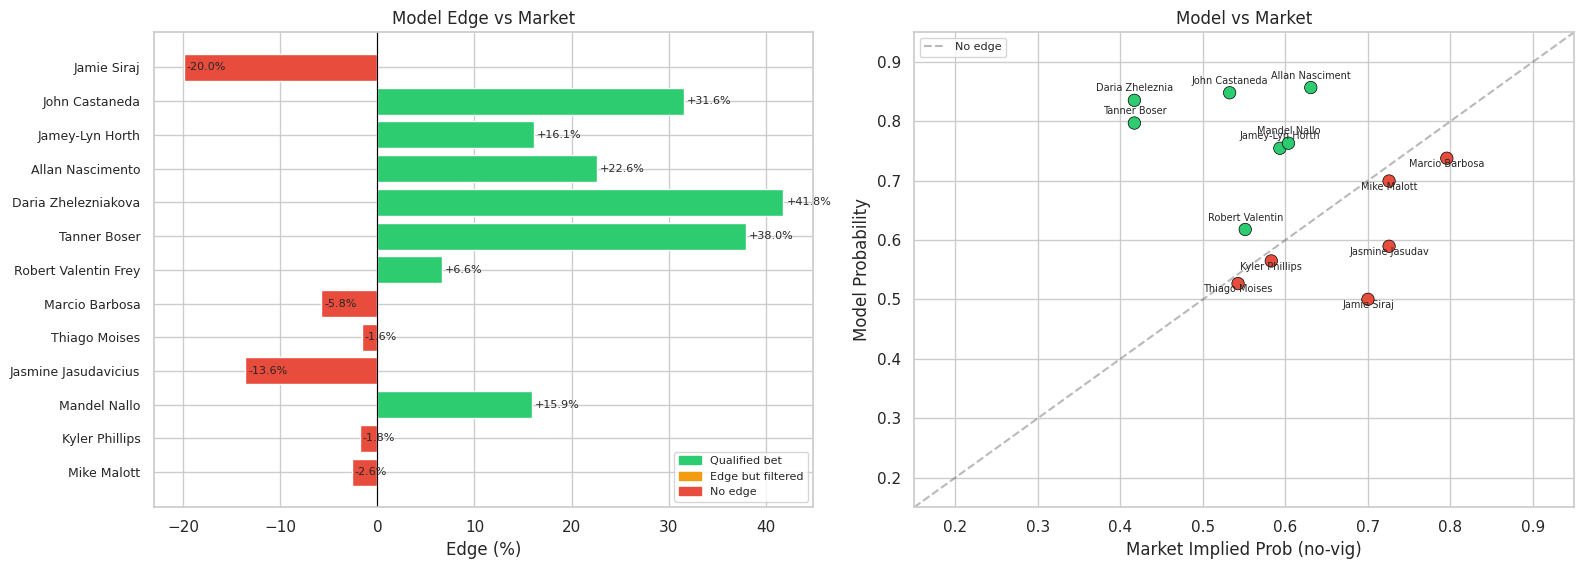

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(bets) * 0.45)))

# -- panel 1: edge bars --
ax = axes[0]
colors = []
for _, r in bets.iterrows():
    if r['edge'] > 0 and r['unanimous'] and r['confidence'] >= 0.55:
        colors.append('#2ecc71')
    elif r['edge'] > 0:
        colors.append('#f39c12')
    else:
        colors.append('#e74c3c')

ax.barh(range(len(bets)), bets['edge'] * 100, color=colors)
ax.set_yticks(range(len(bets)))
ax.set_yticklabels(bets['bet_on'], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Edge (%)')
ax.set_title('Model Edge vs Market')
ax.invert_yaxis()
for i, e in enumerate(bets['edge']):
    ax.text(e * 100 + 0.3, i, f'{e:+.1%}', va='center', fontsize=8)
ax.legend(handles=[Patch(color='#2ecc71', label='Qualified bet'),
                   Patch(color='#f39c12', label='Edge but filtered'),
                   Patch(color='#e74c3c', label='No edge')],
          loc='lower right', fontsize=8)

# -- panel 2: model vs market scatter --
ax = axes[1]
ax.scatter(bets['implied_fair'], bets['model_prob'],
           c=colors, s=80, edgecolors='black', lw=0.5, zorder=3)
ax.plot([0.15, 0.95], [0.15, 0.95], 'k--', alpha=0.3, label='No edge')
for _, r in bets.iterrows():
    nm = r['bet_on'][:15]
    off = 0.015 if r['model_prob'] > r['implied_fair'] else -0.015
    ax.annotate(nm, (r['implied_fair'], r['model_prob'] + off),
                fontsize=7, ha='center')
ax.set_xlabel('Market Implied Prob (no-vig)')
ax.set_ylabel('Model Probability')
ax.set_title('Model vs Market')
ax.legend(fontsize=8)
ax.set_xlim(0.15, 0.95)
ax.set_ylim(0.15, 0.95)

plt.tight_layout()
plt.savefig(DATA / 'betting_edge_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
print('=' * 60)
print('  RISK SUMMARY')
print('=' * 60)

if len(qualified) == 0:
    print('  No bets placed.')
else:
    ts = qualified['stake'].sum()
    n  = len(qualified)

    print(f'  Bets          : {n}')
    print(f'  Total staked  : ${ts:,.2f}  ({ts/BANKROLL:.1%} of roll)')
    print(f"  Largest bet   : ${qualified['stake'].max():,.2f}")
    print(f'  Avg bet       : ${ts/n:,.2f}')
    print()

    # scenario table
    print('  Scenario analysis:')
    sq = qualified.sort_values('stake', ascending=False).reset_index(drop=True)
    for w in range(n + 1):
        pnl = 0
        for j in range(n):
            if j < w:
                pnl += sq.loc[j, 'to_win']
            else:
                pnl -= sq.loc[j, 'stake']
        pct = pnl / BANKROLL
        bar = '#' * max(0, int((pct + 0.5) * 30))
        print(f'    {w}W-{n-w}L : {pnl:>+10,.2f}  ({pct:>+6.1%})  {bar}')

    print()
    print('  Half-Kelly limits exposure but does not eliminate risk.')
    print('  Never bet money you cannot afford to lose.')
print('=' * 60)

  RISK SUMMARY
  Bets          : 7
  Total staked  : $1,032.53  (103.3% of roll)
  Largest bet   : $217.03
  Avg bet       : $147.50

  Scenario analysis:
    0W-7L :  -1,032.53  (-103.3%)  
    1W-6L :    -702.46  (-70.2%)  
    2W-5L :    -347.30  (-34.7%)  ####
    3W-4L :     +22.84  ( +2.3%)  ###############
    4W-3L :    +359.17  (+35.9%)  #########################
    5W-2L :    +574.41  (+57.4%)  ################################
    6W-1L :    +785.72  (+78.6%)  ######################################
    7W-0L :    +863.79  (+86.4%)  ########################################

  Half-Kelly limits exposure but does not eliminate risk.
  Never bet money you cannot afford to lose.


## Results -- run after the event

Re-run **Cell 6** (scrape) to pick up winners, then run the next cell.

In [38]:
# -- build winner lookup from card_df --
wmap = {}
for _, r in card_df.iterrows():
    wmap[(r['fighter_1'], r['fighter_2'])] = r['winner']

bets['actual_winner'] = bets.apply(
    lambda r: wmap.get((r['fighter_1'], r['fighter_2']), ''), axis=1)

has = bets['actual_winner'].str.len() > 0

if has.sum() == 0:
    print('Event not complete yet -- re-run Cell 6 + this cell after it finishes.')
else:
    bets.loc[has, 'correct'] = bets.loc[has, 'bet_on'] == bets.loc[has, 'actual_winner']
    bets.loc[has, 'pnl'] = bets.loc[has].apply(
        lambda r: r['to_win'] if r['correct'] else (-r['stake'] if r['stake'] > 0 else 0),
        axis=1)

    sc = bets.loc[has & (bets['unanimous'] == True)
                      & (bets['confidence'] >= 0.55)
                      & (bets['edge'] > 0)].copy()

    print('=' * 80)
    print(f'  RESULTS -- {event_name}')
    print('=' * 80)
    print()

    if len(sc) == 0:
        print('  No qualified bets were placed.')
    else:
        for _, b in sc.iterrows():
            tag = 'WIN' if b['correct'] else 'LOSS'
            print(f"  [{tag:4s}] {b['bet_on']:25s} ({b['american']:+d})  "
                  f"${b['stake']:.0f} -> P&L ${b['pnl']:+,.2f}")

        tw = int(sc['correct'].sum())
        tl = len(sc) - tw
        tp = sc['pnl'].sum()
        tsk = sc['stake'].sum()
        print(f'\n  Record  : {tw}W-{tl}L ({tw/len(sc):.0%})')
        print(f'  Staked  : ${tsk:,.2f}')
        print(f'  P&L     : ${tp:+,.2f}')
        if tsk > 0:
            print(f'  ROI     : {tp/tsk:+.1%}')
        print(f'  Bankroll: ${BANKROLL:,.0f} -> ${BANKROLL + tp:,.2f}')
        print('=' * 80)

    # all picks accuracy
    ac = bets.loc[has]
    nc = (ac['bet_on'] == ac['actual_winner']).sum()
    print(f'\nAll picks: {nc}/{len(ac)} ({nc/len(ac):.1%})')

    print('\nBy tier:')
    for t in ['VERY_HIGH', 'HIGH', 'MEDIUM', 'LOW', 'NO_CONF']:
        sub = ac[ac['tier'] == t]
        if len(sub):
            c = (sub['bet_on'] == sub['actual_winner']).sum()
            print(f'   {t:10s} {c}/{len(sub)} ({c/len(sub):.0%})')

Event not complete yet -- re-run Cell 6 + this cell after it finishes.


In [39]:
slug = re.sub(r'[^A-Za-z0-9]+', '_', event_name)[:50]
out = DATA / f'bets_{slug}.csv'

bets[['fighter_1','fighter_2','bet_on','american','decimal',
      'model_prob','implied_fair','edge','tier','confidence',
      'unanimous','kelly_frac','stake','to_win','coverage']].to_csv(out, index=False)

print(f'Saved {out}')
print(f'  {len(qualified)} qualified bets  |  {len(bets)} total fights')

Saved data/bets_UFC_Fight_Night_Burns_vs_Malott.csv
  7 qualified bets  |  13 total fights
